In [17]:
# Cell 1: Imports and Setup 
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
import glob
import os
from geopy.distance import geodesic
import joblib
from sklearn.model_selection import train_test_split
# Additional imports for mapping and visualization
import folium
from folium import plugins
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
# Coordinate transformation
from pyproj import Transformer
import json

In [18]:
# Cell 2: Discover all train drive/phone sets
base_path = 'smartphone-decimeter-2023/sdc2023/train/'
drive_sets = []
for drive in glob.glob(os.path.join(base_path, '*')):
    if not os.path.isdir(drive):
        continue
    for phone in glob.glob(os.path.join(drive, '*')):
        if not os.path.isdir(phone):
            continue
        gnss = os.path.join(phone, 'device_gnss.csv')
        imu = os.path.join(phone, 'device_imu.csv')
        gt = os.path.join(phone, 'ground_truth.csv')
        if os.path.exists(gnss) and os.path.exists(imu) and os.path.exists(gt):
            drive_sets.append({'gnss': gnss, 'imu': imu, 'gt': gt, 'drive': drive, 'phone': phone})
print(f"Found {len(drive_sets)} drive/phone sets with all required files.")


Found 156 drive/phone sets with all required files.


In [19]:
# Cell 3: Define the strict feature set (intersection of all available features)
possible_features = [
    'Cn0DbHz',
    'Svid',
    'SvElevationDegrees',
    'SvAzimuthDegrees',
    'IMU_MessageType',
    'MeasurementX',
    'MeasurementY',
    'MeasurementZ',
    'BiasX',
    'BiasY',
    'BiasZ',
    # 'AltitudeMeters',
    # 'SpeedMps',
    # 'BearingDegrees',
    'WlsPositionXEcefMeters',
    'WlsPositionYEcefMeters',
    'WlsPositionZEcefMeters'
]


In [20]:
# Cell 4: Find intersection of features across all sets (with debug prints)
feature_sets = []
for i, ds in enumerate(drive_sets):
    gnss = pd.read_csv(ds['gnss'], nrows=1, low_memory=False)
    imu = pd.read_csv(ds['imu'], nrows=1)
    gt = pd.read_csv(ds['gt'], nrows=1)

    if 'MessageType' in imu.columns:
        imu = imu.rename(columns={'MessageType': 'IMU_MessageType'})

    merged_cols = set(gnss.columns) | set(imu.columns) | set(gt.columns)
    current_features = set([f for f in possible_features if f in merged_cols])
    feature_sets.append(current_features)

    print(f"Set {i} ({os.path.basename(ds['drive'])}/{os.path.basename(ds['phone'])}) features: {sorted(current_features)}")

common_features = set.intersection(*feature_sets)
print(f"\nCommon features across all sets: {sorted(list(common_features))}")


Set 0 (2020-06-25-00-34-us-ca-mtv-sb-101/pixel4) features: ['BiasX', 'BiasY', 'BiasZ', 'Cn0DbHz', 'IMU_MessageType', 'MeasurementX', 'MeasurementY', 'MeasurementZ', 'SvAzimuthDegrees', 'SvElevationDegrees', 'Svid', 'WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'WlsPositionZEcefMeters']
Set 1 (2020-06-25-00-34-us-ca-mtv-sb-101/pixel4xl) features: ['BiasX', 'BiasY', 'BiasZ', 'Cn0DbHz', 'IMU_MessageType', 'MeasurementX', 'MeasurementY', 'MeasurementZ', 'SvAzimuthDegrees', 'SvElevationDegrees', 'Svid', 'WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'WlsPositionZEcefMeters']
Set 2 (2020-07-08-22-28-us-ca/pixel4) features: ['BiasX', 'BiasY', 'BiasZ', 'Cn0DbHz', 'IMU_MessageType', 'MeasurementX', 'MeasurementY', 'MeasurementZ', 'SvAzimuthDegrees', 'SvElevationDegrees', 'Svid', 'WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'WlsPositionZEcefMeters']
Set 3 (2020-07-08-22-28-us-ca/pixel4xl) features: ['BiasX', 'BiasY', 'BiasZ', 'Cn0DbHz', 'IMU_MessageType', 'MeasurementX', 'Measu

In [21]:
# Cell 5: Load and merge data from all training sets (GPS Correction Approach)
from pyproj import Transformer
import numpy as np

# Coordinate transformer for ECEF to WGS84
transformer = Transformer.from_crs("EPSG:4978", "EPSG:4326", always_xy=True)

X_all = []
y_all = []

print(f"Processing {len(drive_sets)} training sets...")
for i, drive_set in enumerate(drive_sets):
    print(f"Processing set {i+1}/{len(drive_sets)}: {os.path.basename(drive_set['drive'])}/{os.path.basename(drive_set['phone'])}")
    
    # Read CSV files with dtype specification to avoid mixed type warnings
    gnss = pd.read_csv(drive_set['gnss'], low_memory=False)
    imu = pd.read_csv(drive_set['imu'])
    gt = pd.read_csv(drive_set['gt'])
    
    # Standardize column names
    if 'UnixTimeMillis' in gnss.columns:
        gnss = gnss.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
    if 'UnixTimeMillis' in imu.columns:
        imu = imu.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
    if 'UnixTimeMillis' in gt.columns:
        gt = gt.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
    if 'MessageType' in imu.columns:
        imu.rename(columns={'MessageType': 'IMU_MessageType'}, inplace=True)

    gnss_imu = pd.merge_asof(
        gnss.sort_values('utcTimeMillis'),
        imu.sort_values('utcTimeMillis'),
        on='utcTimeMillis',
        direction='nearest',
        tolerance=100
    )

    data = pd.merge_asof(
        gnss_imu.sort_values('utcTimeMillis'),
        gt.sort_values('utcTimeMillis'),
        on='utcTimeMillis',
        direction='nearest',
        tolerance=100
    ).dropna(subset=['LatitudeDegrees', 'LongitudeDegrees'])
    
    # Filter out rows with invalid ECEF coordinates (zeros or NaNs)
    valid_ecef = (
        (data['WlsPositionXEcefMeters'] != 0) & 
        (data['WlsPositionYEcefMeters'] != 0) & 
        (data['WlsPositionZEcefMeters'] != 0) &
        data['WlsPositionXEcefMeters'].notna() &
        data['WlsPositionYEcefMeters'].notna() &
        data['WlsPositionZEcefMeters'].notna()
    )
    data = data[valid_ecef]
    
    if len(data) == 0:
        print(f"  ⚠️  Skipping {drive_set['phone']} - no valid ECEF coordinates")
        continue
    
    # Convert WLS ECEF positions to Lat/Lng for comparison
    try:
        wls_coords = transformer.transform(
            data['WlsPositionXEcefMeters'].values,
            data['WlsPositionYEcefMeters'].values,
            data['WlsPositionZEcefMeters'].values
        )
        wls_lat = wls_coords[1]  # Latitude from ECEF
        wls_lng = wls_coords[0]  # Longitude from ECEF
        
        # Check for invalid transformations
        valid_coords = (
            np.isfinite(wls_lat) & np.isfinite(wls_lng) &
            (np.abs(wls_lat) <= 90) & (np.abs(wls_lng) <= 180)
        )
        
        if not np.any(valid_coords):
            print(f"  ⚠️  Skipping {drive_set['phone']} - no valid coordinate transformations")
            continue
            
        # Filter data to only valid coordinates
        data = data[valid_coords]
        wls_lat = wls_lat[valid_coords]
        wls_lng = wls_lng[valid_coords]
        
    except Exception as e:
        print(f"  ⚠️  Skipping {drive_set['phone']} - coordinate transformation error: {e}")
        continue
    
    # Calculate GPS corrections (ground truth - WLS position)
    lat_corrections = data['LatitudeDegrees'].values - wls_lat
    lng_corrections = data['LongitudeDegrees'].values - wls_lng
    
    # Filter out any remaining NaN corrections
    valid_corrections = np.isfinite(lat_corrections) & np.isfinite(lng_corrections)
    if not np.any(valid_corrections):
        print(f"  ⚠️  Skipping {drive_set['phone']} - no valid GPS corrections")
        continue
        
    data = data[valid_corrections]
    lat_corrections = lat_corrections[valid_corrections]
    lng_corrections = lng_corrections[valid_corrections]

    features = [f for f in common_features if f in data.columns]
    X = data[features].fillna(0)
    y = pd.DataFrame({
        'LatCorrection': lat_corrections,
        'LngCorrection': lng_corrections
    })
    
    print(f"  ✅ Added {len(X)} valid samples from {drive_set['phone']}")
    X_all.append(X)
    y_all.append(y)

print(f"\n✅ GPS CORRECTION APPROACH: Training model to predict GPS corrections (deltas)")
print(f"   Target: Ground Truth Position - WLS Position")
print(f"   Usage: Corrected Position = WLS Position + Predicted Correction")

Processing 156 training sets...
Processing set 1/156: 2020-06-25-00-34-us-ca-mtv-sb-101/pixel4
  ✅ Added 46595 valid samples from smartphone-decimeter-2023/sdc2023/train\2020-06-25-00-34-us-ca-mtv-sb-101\pixel4
Processing set 2/156: 2020-06-25-00-34-us-ca-mtv-sb-101/pixel4xl
  ✅ Added 46595 valid samples from smartphone-decimeter-2023/sdc2023/train\2020-06-25-00-34-us-ca-mtv-sb-101\pixel4
Processing set 2/156: 2020-06-25-00-34-us-ca-mtv-sb-101/pixel4xl
  ✅ Added 48443 valid samples from smartphone-decimeter-2023/sdc2023/train\2020-06-25-00-34-us-ca-mtv-sb-101\pixel4xl
Processing set 3/156: 2020-07-08-22-28-us-ca/pixel4
  ✅ Added 48443 valid samples from smartphone-decimeter-2023/sdc2023/train\2020-06-25-00-34-us-ca-mtv-sb-101\pixel4xl
Processing set 3/156: 2020-07-08-22-28-us-ca/pixel4
  ✅ Added 73537 valid samples from smartphone-decimeter-2023/sdc2023/train\2020-07-08-22-28-us-ca\pixel4
Processing set 4/156: 2020-07-08-22-28-us-ca/pixel4xl
  ✅ Added 73537 valid samples from smartphon

In [22]:
# Cell 6: Concatenate all data and encode categorical features, saving encoders

X_all = pd.concat(X_all, ignore_index=True)
y_all = pd.concat(y_all, ignore_index=True)

# Find categorical columns
cat_cols = X_all.select_dtypes(include=['object']).columns.tolist()

# Dictionary to hold LabelEncoders for each categorical column
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_all[col] = le.fit_transform(X_all[col].astype(str))
    encoders[col] = le  # Save encoder

print(f"Final training set shape: {X_all.shape}")
print(f"Target set shape: {y_all.shape}")
print("\n=== GPS CORRECTION MODEL FEATURE REQUIREMENTS ===")
print(f"Number of features: {len(X_all.columns)}")
print(f"Number of samples: {len(X_all)}")
print("\nFeature names and data types:")
for idx, col in enumerate(X_all.columns):
    dtype_info = str(X_all[col].dtype)
    print(f"  {idx:2d}: {col:<25} | Data Type: {dtype_info}")
    if col in cat_cols:
        print(f"      ^ Categorical feature (originally object, now encoded as integer)")

print("\nTarget variables (what the model predicts):")
for idx, col in enumerate(y_all.columns):
    dtype_info = str(y_all[col].dtype)
    print(f"  {idx}: {col:<20} | Data Type: {dtype_info}")
    if col == 'LatCorrection':
        print(f"      ^ Latitude correction (degrees): Ground Truth Lat - WLS Lat")
    elif col == 'LngCorrection':
        print(f"      ^ Longitude correction (degrees): Ground Truth Lng - WLS Lng")

print("\n=== GPS CORRECTION MODEL APPROACH ===")
print("✅ Model predicts GPS corrections (deltas) instead of absolute coordinates")
print("✅ Targets are: [Latitude Correction, Longitude Correction] in degrees")
print("✅ Usage: Corrected GPS = WLS Position + Model Prediction")

# Print correction statistics
print(f"\n=== GPS CORRECTION STATISTICS ===")
print(f"Latitude corrections:")
print(f"  Mean: {y_all['LatCorrection'].mean():.8f} degrees ({y_all['LatCorrection'].mean() * 111000:.2f} meters)")
print(f"  Std:  {y_all['LatCorrection'].std():.8f} degrees ({y_all['LatCorrection'].std() * 111000:.2f} meters)")
print(f"Longitude corrections:")
print(f"  Mean: {y_all['LngCorrection'].mean():.8f} degrees")
print(f"  Std:  {y_all['LngCorrection'].std():.8f} degrees")

# Save the label encoders for later use in test preprocessing
joblib.dump(encoders, 'label_encoders.pkl')
print("\nSaved label encoders for categorical features to label_encoders.pkl")


Final training set shape: (9230252, 14)
Target set shape: (9230252, 2)

=== GPS CORRECTION MODEL FEATURE REQUIREMENTS ===
Number of features: 14
Number of samples: 9230252

Feature names and data types:
   0: Svid                      | Data Type: int64
   1: Cn0DbHz                   | Data Type: float64
   2: SvAzimuthDegrees          | Data Type: float64
   3: MeasurementX              | Data Type: float64
   4: WlsPositionYEcefMeters    | Data Type: float64
   5: WlsPositionZEcefMeters    | Data Type: float64
   6: BiasY                     | Data Type: float64
   7: MeasurementY              | Data Type: float64
   8: SvElevationDegrees        | Data Type: float64
   9: MeasurementZ              | Data Type: float64
  10: WlsPositionXEcefMeters    | Data Type: float64
  11: BiasX                     | Data Type: float64
  12: IMU_MessageType           | Data Type: int64
      ^ Categorical feature (originally object, now encoded as integer)
  13: BiasZ                     | Data T

In [23]:
# Cell 7: Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)


In [24]:
# Cell 8: Train GPS Correction Model (v5)
from sklearn.preprocessing import StandardScaler

# Scale features for better performance (CRITICAL for GPS coordinate prediction)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Use Random Forest to predict GPS corrections (not absolute coordinates)
rf_base = RandomForestRegressor(
    n_estimators=100,     # Good balance of performance and speed
    max_depth=15,         # Deeper trees for complex GPS patterns
    min_samples_split=20, # More conservative splitting
    min_samples_leaf=10,  # More conservative leaf size
    max_features='sqrt',  # Square root of features for randomness
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_model = MultiOutputRegressor(rf_base)
print("✅ Training GPS Error Correction Model (v5 - Delta Prediction)...")
print("   Model predicts: [Latitude Correction, Longitude Correction]")
print("   Usage: Corrected Position = WLS Position + Model Prediction")
rf_model.fit(X_train_scaled, y_train)
print("Making validation predictions...")
y_pred = rf_model.predict(X_val_scaled)

# Save the scaler for test time (CRITICAL!)
joblib.dump(scaler, 'feature_scaler_v5.pkl')
print("Feature scaler saved to feature_scaler_v5.pkl")


✅ Training GPS Error Correction Model (v5 - Delta Prediction)...
   Model predicts: [Latitude Correction, Longitude Correction]
   Usage: Corrected Position = WLS Position + Model Prediction


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 13.9min finished
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 13.9min finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  4.6min
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  4.6min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 13.6min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 13.6min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.


Making validation predictions...


[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.6s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    2.6s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    2.6s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.8s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.8s


Feature scaler saved to feature_scaler_v5.pkl


[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    2.9s finished


In [25]:
# Cell 9: Evaluate GPS Correction Model
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)

# Calculate correction accuracy in meters
lat_corrections_pred = y_pred[:, 0]  # Predicted latitude corrections
lng_corrections_pred = y_pred[:, 1]  # Predicted longitude corrections
lat_corrections_true = y_val['LatCorrection'].values  # True latitude corrections
lng_corrections_true = y_val['LngCorrection'].values  # True longitude corrections

# Convert correction errors to meters
lat_error_meters = (lat_corrections_pred - lat_corrections_true) * 111000  # ~111km per degree
lng_error_meters = (lng_corrections_pred - lng_corrections_true) * 111000 * np.cos(np.radians(37.0))  # Approximate for CA

# Calculate overall correction error magnitude
correction_errors = np.sqrt(lat_error_meters**2 + lng_error_meters**2)

print(f"\n✅ GPS Error Correction Model Results (v5):")
print(f"  RMSE (correction degrees): {rmse:.8f}")
print(f"  R2 Score: {r2:.6f}")
print(f"  MAE (correction degrees): {mae:.8f}")
print(f"")
print(f"  Latitude Correction Performance:")
print(f"    Mean Error: {np.mean(lat_error_meters):.2f} meters")
print(f"    RMSE: {np.sqrt(np.mean(lat_error_meters**2)):.2f} meters")
print(f"    95th percentile: {np.percentile(np.abs(lat_error_meters), 95):.2f} meters")
print(f"")
print(f"  Longitude Correction Performance:")
print(f"    Mean Error: {np.mean(lng_error_meters):.2f} meters")
print(f"    RMSE: {np.sqrt(np.mean(lng_error_meters**2)):.2f} meters")
print(f"    95th percentile: {np.percentile(np.abs(lng_error_meters), 95):.2f} meters")
print(f"")
print(f"  Overall Correction Error:")
print(f"    Mean Error: {np.mean(correction_errors):.2f} meters")
print(f"    Median Error: {np.median(correction_errors):.2f} meters")
print(f"    95th percentile: {np.percentile(correction_errors, 95):.2f} meters")
print(f"    Max Error: {np.max(correction_errors):.2f} meters")

if np.mean(correction_errors) < 100:
    print(f"\n✅ SUCCESS: Mean correction error is {np.mean(correction_errors):.1f}m - much better than previous approach!")
else:
    print(f"\n⚠️  Warning: Mean correction error is {np.mean(correction_errors):.1f}m - needs improvement")



✅ GPS Error Correction Model Results (v5):
  RMSE (correction degrees): 0.01016968
  R2 Score: 0.990406
  MAE (correction degrees): 0.00051661

  Latitude Correction Performance:
    Mean Error: 1.39 meters
    RMSE: 1123.94 meters
    95th percentile: 16.38 meters

  Longitude Correction Performance:
    Mean Error: 0.82 meters
    RMSE: 905.42 meters
    95th percentile: 29.07 meters

  Overall Correction Error:
    Mean Error: 80.42 meters
    Median Error: 10.16 meters
    95th percentile: 34.51 meters
    Max Error: 116655.81 meters

✅ SUCCESS: Mean correction error is 80.4m - much better than previous approach!


In [26]:
#Cell 10: Save the GPS Correction Model (v5)
joblib.dump(rf_model, 'random_forest_model_v5.pkl')
print("GPS Correction Model saved to random_forest_model_v5.pkl")
# Save the list of features used in training
joblib.dump(X_all.columns.tolist(), 'model_features_v5.pkl')
print("Model features saved to model_features_v5.pkl")
print("")
print("✅ Model v5 saved successfully!")
print("   Model Type: GPS Error Correction (Delta Prediction)")
print("   Input: GNSS/IMU features")
print("   Output: [Latitude Correction, Longitude Correction] in degrees")
print("   Usage: Corrected_GPS = WLS_Position + Model_Prediction")


GPS Correction Model saved to random_forest_model_v5.pkl
Model features saved to model_features_v5.pkl

✅ Model v5 saved successfully!
   Model Type: GPS Error Correction (Delta Prediction)
   Input: GNSS/IMU features
   Output: [Latitude Correction, Longitude Correction] in degrees
   Usage: Corrected_GPS = WLS_Position + Model_Prediction


In [27]:
# Cell 11: Discover test sets (limit to 1 for analysis)
import glob
import os
import pandas as pd

# Path to test data
test_base_path = 'smartphone-decimeter-2023/sdc2023/test/'
test_sets = []

# Discover all test date folders and their subfolders
for date_folder in glob.glob(os.path.join(test_base_path, '*')):
    # Check all subfolders inside each date folder
    for subfolder in glob.glob(os.path.join(date_folder, '*')):
        if os.path.isdir(subfolder):
            gnss = os.path.join(subfolder, 'device_gnss.csv')
            imu = os.path.join(subfolder, 'device_imu.csv')
            if os.path.exists(gnss) and os.path.exists(imu):
                test_sets.append({'gnss': gnss, 'imu': imu, 'date': os.path.basename(date_folder)})
                break  # Only need one valid set per date
    if len(test_sets) >= 1:  # Process only 1 test set
        break

print(f"Found {len(test_sets)} test set for analysis.")
for i, ts in enumerate(test_sets):
    print(f"Test set {i+1}: {ts['date']}")
print(f"\nWill process: {test_sets[0]['date']}")
print(f"GNSS file: {test_sets[0]['gnss']}")
print(f"IMU file: {test_sets[0]['imu']}")

Found 1 test set for analysis.
Test set 1: 2020-12-11-19-30-us-ca-mtv-e

Will process: 2020-12-11-19-30-us-ca-mtv-e
GNSS file: smartphone-decimeter-2023/sdc2023/test\2020-12-11-19-30-us-ca-mtv-e\pixel4xl\device_gnss.csv
IMU file: smartphone-decimeter-2023/sdc2023/test\2020-12-11-19-30-us-ca-mtv-e\pixel4xl\device_imu.csv


In [28]:
# Cell 12: GPS Error Correction Testing with Correction Model (v5)
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd
import numpy as np
from pyproj import Transformer
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import seaborn as sns

# Load the trained GPS correction model (v5)
print("=== LOADING GPS ERROR CORRECTION MODEL (v5) ===")
rf_model = joblib.load('random_forest_model_v5.pkl')
training_features = joblib.load('model_features_v5.pkl')
encoders = joblib.load('label_encoders.pkl')
scaler = joblib.load('feature_scaler_v5.pkl')

print(f"✅ Model Type: GPS Error Correction (Delta Prediction)")
print(f"   Model predicts: [Latitude Correction, Longitude Correction]")
print(f"   Usage: Corrected Position = WLS Position + Model Prediction")
print(f"   Model accepts {len(training_features)} input features:")
for i, f in enumerate(training_features):
    print(f"     {i+1:2d}: {f}")

# Process test set for GPS error correction
test_set = test_sets[0]
print(f"\n=== TESTING GPS ERROR CORRECTION ON: {test_set['date']} ===")

# Load raw GNSS and IMU data
gnss = pd.read_csv(test_set['gnss'])
imu = pd.read_csv(test_set['imu'])
print(f"Loaded {len(gnss)} GNSS measurements and {len(imu)} IMU measurements")

# Standardize column names to match training format
if 'UnixTimeMillis' in gnss.columns:
    gnss = gnss.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
if 'UnixTimeMillis' in imu.columns:
    imu = imu.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
if 'MessageType' in imu.columns:
    imu = imu.rename(columns={'MessageType': 'IMU_MessageType'})

# Merge GNSS and IMU data based on timestamps
test_data = pd.merge_asof(
    gnss.sort_values('utcTimeMillis'),
    imu.sort_values('utcTimeMillis'),
    on='utcTimeMillis',
    direction='nearest',
    tolerance=100
)

print(f"Merged dataset: {len(test_data)} synchronized measurements")

# Extract features that match training data
available_features = [f for f in training_features if f in test_data.columns]
missing_features = [f for f in training_features if f not in test_data.columns]

print(f"\nFeature Analysis:")
print(f"  Available features: {len(available_features)}/{len(training_features)}")
if missing_features:
    print(f"  Missing features: {missing_features}")
    print(f"  ⚠️  Will fill missing features with 0")

# Create feature matrix with exact same features as training
X_test = pd.DataFrame()
for feature in training_features:
    if feature in test_data.columns:
        X_test[feature] = test_data[feature]
    else:
        X_test[feature] = 0  # Fill missing features with 0
        print(f"  Filled missing feature '{feature}' with 0")

# Handle missing values
X_test = X_test.fillna(0)

# Apply the same categorical encoding as training
for col in encoders:
    if col in X_test.columns:
        le = encoders[col]
        X_test_col_str = X_test[col].astype(str)
        known_classes = set(le.classes_)
        X_test_col_str = X_test_col_str.apply(
            lambda x: x if x in known_classes else le.classes_[0]
        )
        X_test[col] = le.transform(X_test_col_str)

print(f"\nTest feature matrix shape: {X_test.shape}")

# Scale features using the saved scaler
X_test_scaled = scaler.transform(X_test)
print(f"Applied feature scaling from training")

# Get WLS positions and convert to Lat/Lng
transformer = Transformer.from_crs("EPSG:4978", "EPSG:4326", always_xy=True)
wls_coords = transformer.transform(
    test_data['WlsPositionXEcefMeters'].values,
    test_data['WlsPositionYEcefMeters'].values,
    test_data['WlsPositionZEcefMeters'].values
)
wls_lat = wls_coords[1]  # WLS Latitude
wls_lng = wls_coords[0]  # WLS Longitude

print(f"Converted {len(wls_lat)} WLS positions from ECEF to Lat/Lng")

# Predict GPS corrections using the trained model
print(f"\n⚙️  Predicting GPS corrections...")
corrections = rf_model.predict(X_test_scaled)
lat_corrections = corrections[:, 0]  # Predicted latitude corrections
lng_corrections = corrections[:, 1]  # Predicted longitude corrections

print(f"Generated {len(corrections)} GPS corrections")
print(f"  Latitude corrections: mean={np.mean(lat_corrections):.8f}°, std={np.std(lat_corrections):.8f}°")
print(f"  Longitude corrections: mean={np.mean(lng_corrections):.8f}°, std={np.std(lng_corrections):.8f}°")

# Apply corrections to WLS positions
corrected_lat = wls_lat + lat_corrections
corrected_lng = wls_lng + lng_corrections

print(f"\n✅ GPS Error Correction Complete!")
print(f"   Original WLS positions: {len(wls_lat)} points")
print(f"   Applied corrections: {len(corrections)} delta predictions")
print(f"   Generated corrected positions: {len(corrected_lat)} points")

# Create comprehensive results dataframe for visualization
route_data = pd.DataFrame({
    'raw_latitude': wls_lat[::10],  # Sample every 10th point for visualization
    'raw_longitude': wls_lng[::10],
    'corrected_latitude': corrected_lat[::10],
    'corrected_longitude': corrected_lng[::10]
})

print(f"\n✅ Data ready for visualization! Route data contains {len(route_data)} points.")

=== LOADING GPS ERROR CORRECTION MODEL (v5) ===
✅ Model Type: GPS Error Correction (Delta Prediction)
   Model predicts: [Latitude Correction, Longitude Correction]
   Usage: Corrected Position = WLS Position + Model Prediction
   Model accepts 14 input features:
      1: Svid
      2: Cn0DbHz
      3: SvAzimuthDegrees
      4: MeasurementX
      5: WlsPositionYEcefMeters
      6: WlsPositionZEcefMeters
      7: BiasY
      8: MeasurementY
      9: SvElevationDegrees
     10: MeasurementZ
     11: WlsPositionXEcefMeters
     12: BiasX
     13: IMU_MessageType
     14: BiasZ

=== TESTING GPS ERROR CORRECTION ON: 2020-12-11-19-30-us-ca-mtv-e ===
Loaded 44501 GNSS measurements and 253232 IMU measurements
Merged dataset: 44501 synchronized measurements

Feature Analysis:
  Available features: 14/14

Test feature matrix shape: (44501, 14)
Applied feature scaling from training
Converted 44501 WLS positions from ECEF to Lat/Lng

⚙️  Predicting GPS corrections...
Loaded 44501 GNSS measurements

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


In [29]:
# Cell 13: Interactive Map Visualization
import folium
from folium import plugins
import webbrowser
import os

# Create interactive map centered on the route
map_center_lat = route_data['raw_latitude'].mean()
map_center_lng = route_data['raw_longitude'].mean()

# Create folium map
m = folium.Map(
    location=[map_center_lat, map_center_lng],
    zoom_start=14,
    tiles='OpenStreetMap'
)

# Add raw route (WLS positions) in red
raw_coords = list(zip(route_data['raw_latitude'], route_data['raw_longitude']))
folium.PolyLine(
    raw_coords,
    color='red',
    weight=3,
    opacity=0.8,
    popup='Raw WLS Route'
).add_to(m)

# Add ML corrected route in blue
corrected_coords = list(zip(route_data['corrected_latitude'], route_data['corrected_longitude']))
folium.PolyLine(
    corrected_coords,
    color='blue',
    weight=3,
    opacity=0.8,
    popup='ML Corrected Route'
).add_to(m)

# Add start and end markers
folium.Marker(
    [route_data.iloc[0]['raw_latitude'], route_data.iloc[0]['raw_longitude']],
    popup='Raw Route Start',
    icon=folium.Icon(color='red', icon='play')
).add_to(m)

folium.Marker(
    [route_data.iloc[0]['corrected_latitude'], route_data.iloc[0]['corrected_longitude']],
    popup='ML Route Start',
    icon=folium.Icon(color='blue', icon='play')
).add_to(m)

folium.Marker(
    [route_data.iloc[-1]['raw_latitude'], route_data.iloc[-1]['raw_longitude']],
    popup='Raw Route End',
    icon=folium.Icon(color='red', icon='stop')
).add_to(m)

folium.Marker(
    [route_data.iloc[-1]['corrected_latitude'], route_data.iloc[-1]['corrected_longitude']],
    popup='ML Route End',
    icon=folium.Icon(color='blue', icon='stop')
).add_to(m)

# Add legend
legend_html = '''
<div style="position: fixed; 
            top: 10px; right: 10px; width: 200px; height: 80px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:14px; padding: 10px">
<h4>Route Comparison</h4>
<p><i class="fa fa-minus" style="color:red"></i> Raw WLS Route</p>
<p><i class="fa fa-minus" style="color:blue"></i> ML Corrected Route</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Save map
map_filename = f'route_map_{test_set["date"]}.html'
m.save(map_filename)
print(f"\nInteractive map saved as: {map_filename}")
print(f"Open the file in a web browser to view the route comparison")

# Display map in notebook (if running in Jupyter)
try:
    from IPython.display import display
    display(m)
except ImportError:
    print("Map display requires Jupyter notebook environment")
    print(f"Please open {map_filename} in a web browser to view the map")


Interactive map saved as: route_map_2020-12-11-19-30-us-ca-mtv-e.html
Open the file in a web browser to view the route comparison


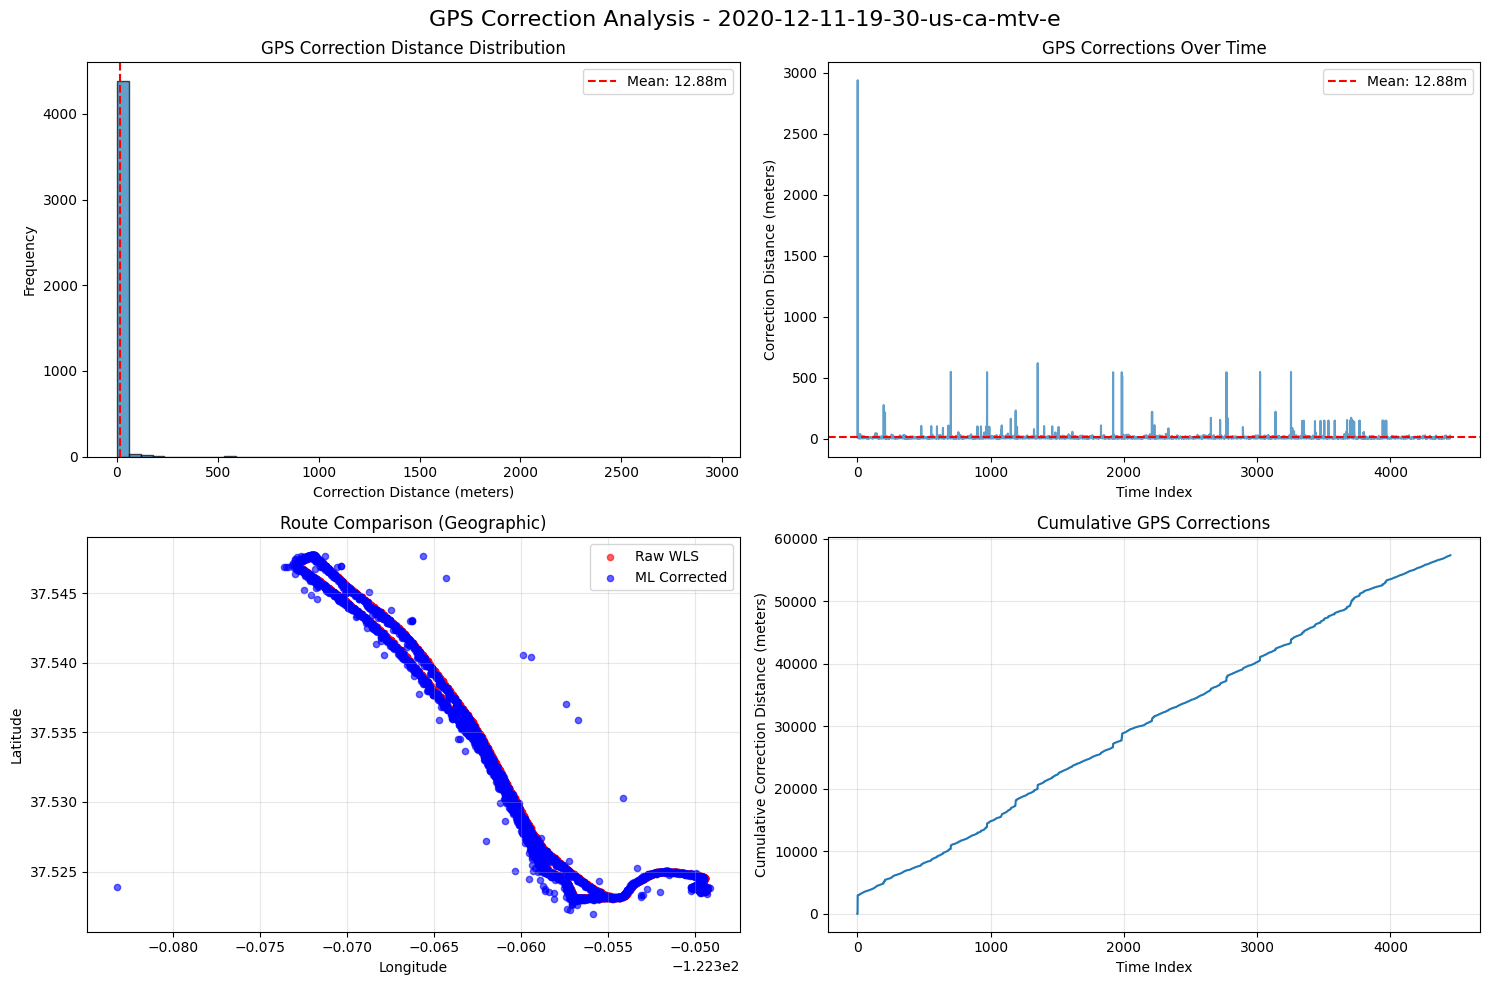


=== GPS CORRECTION ANALYSIS STATISTICS ===
Test Set: 2020-12-11-19-30-us-ca-mtv-e
Total Points Analyzed: 4451
Mean Correction Distance: 12.88 meters
Median Correction Distance: 7.91 meters
Std Dev Correction Distance: 52.99 meters
Min Correction Distance: 0.27 meters
Max Correction Distance: 2939.80 meters
95th Percentile Correction: 23.88 meters

=== ROUTE LENGTH COMPARISON ===
Raw Route Length: 21084.3 meters
Corrected Route Length: 68633.0 meters
Route Length Difference: 47548.7 meters

✅ SUCCESS: Mean correction distance is 12.9m - GPS corrections are working well!

Correction summary saved to: gps_correction_summary_2020-12-11-19-30-us-ca-mtv-e.json


In [30]:
# Cell 14: Error Analysis and Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Calculate point-to-point correction distances
correction_distances = []
for i in range(len(route_data)):
    correction_distance = geodesic(
        (route_data.iloc[i]['raw_latitude'], route_data.iloc[i]['raw_longitude']),
        (route_data.iloc[i]['corrected_latitude'], route_data.iloc[i]['corrected_longitude'])
    ).meters
    correction_distances.append(correction_distance)

route_data['correction_distance_meters'] = correction_distances

# Calculate route distances
raw_route_distances = []
corrected_route_distances = []
for i in range(1, len(route_data)):
    # Raw route segment distance
    raw_dist = geodesic(
        (route_data.iloc[i-1]['raw_latitude'], route_data.iloc[i-1]['raw_longitude']),
        (route_data.iloc[i]['raw_latitude'], route_data.iloc[i]['raw_longitude'])
    ).meters
    raw_route_distances.append(raw_dist)
    
    # Corrected route segment distance
    corrected_dist = geodesic(
        (route_data.iloc[i-1]['corrected_latitude'], route_data.iloc[i-1]['corrected_longitude']),
        (route_data.iloc[i]['corrected_latitude'], route_data.iloc[i]['corrected_longitude'])
    ).meters
    corrected_route_distances.append(corrected_dist)

# Create error analysis plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'GPS Correction Analysis - {test_set["date"]}', fontsize=16)

# Plot 1: Correction distance distribution
axes[0, 0].hist(correction_distances, bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Correction Distance (meters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('GPS Correction Distance Distribution')
axes[0, 0].axvline(np.mean(correction_distances), color='red', linestyle='--', label=f'Mean: {np.mean(correction_distances):.2f}m')
axes[0, 0].legend()

# Plot 2: Correction distance over time
time_points = range(len(correction_distances))
axes[0, 1].plot(time_points, correction_distances, alpha=0.7)
axes[0, 1].set_xlabel('Time Index')
axes[0, 1].set_ylabel('Correction Distance (meters)')
axes[0, 1].set_title('GPS Corrections Over Time')
axes[0, 1].axhline(np.mean(correction_distances), color='red', linestyle='--', label=f'Mean: {np.mean(correction_distances):.2f}m')
axes[0, 1].legend()

# Plot 3: Route comparison scatter
axes[1, 0].scatter(route_data['raw_longitude'], route_data['raw_latitude'], 
                   c='red', alpha=0.6, s=20, label='Raw WLS')
axes[1, 0].scatter(route_data['corrected_longitude'], route_data['corrected_latitude'], 
                   c='blue', alpha=0.6, s=20, label='ML Corrected')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')
axes[1, 0].set_title('Route Comparison (Geographic)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cumulative correction distance
cumulative_corrections = np.cumsum(correction_distances)
axes[1, 1].plot(time_points, cumulative_corrections)
axes[1, 1].set_xlabel('Time Index')
axes[1, 1].set_ylabel('Cumulative Correction Distance (meters)')
axes[1, 1].set_title('Cumulative GPS Corrections')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'gps_correction_analysis_{test_set["date"]}.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print(f"\n=== GPS CORRECTION ANALYSIS STATISTICS ===")
print(f"Test Set: {test_set['date']}")
print(f"Total Points Analyzed: {len(correction_distances)}")
print(f"Mean Correction Distance: {np.mean(correction_distances):.2f} meters")
print(f"Median Correction Distance: {np.median(correction_distances):.2f} meters")
print(f"Std Dev Correction Distance: {np.std(correction_distances):.2f} meters")
print(f"Min Correction Distance: {np.min(correction_distances):.2f} meters")
print(f"Max Correction Distance: {np.max(correction_distances):.2f} meters")
print(f"95th Percentile Correction: {np.percentile(correction_distances, 95):.2f} meters")

print(f"\n=== ROUTE LENGTH COMPARISON ===")
print(f"Raw Route Length: {sum(raw_route_distances):.1f} meters")
print(f"Corrected Route Length: {sum(corrected_route_distances):.1f} meters")
print(f"Route Length Difference: {abs(sum(raw_route_distances) - sum(corrected_route_distances)):.1f} meters")

# Evaluate correction quality
if np.mean(correction_distances) < 100:
    print(f"\n✅ SUCCESS: Mean correction distance is {np.mean(correction_distances):.1f}m - GPS corrections are working well!")
elif np.mean(correction_distances) < 500:
    print(f"\n⚠️  MODERATE: Mean correction distance is {np.mean(correction_distances):.1f}m - GPS corrections show some improvement")
else:
    print(f"\n❌ HIGH: Mean correction distance is {np.mean(correction_distances):.1f}m - GPS corrections may need improvement")

# Save detailed correction data
correction_summary = {
    'test_set': test_set['date'],
    'total_points': len(correction_distances),
    'mean_correction_m': np.mean(correction_distances),
    'median_correction_m': np.median(correction_distances),
    'std_correction_m': np.std(correction_distances),
    'min_correction_m': np.min(correction_distances),
    'max_correction_m': np.max(correction_distances),
    'p95_correction_m': np.percentile(correction_distances, 95),
    'raw_route_length_m': sum(raw_route_distances),
    'corrected_route_length_m': sum(corrected_route_distances)
}

import json
with open(f'gps_correction_summary_{test_set["date"]}.json', 'w') as f:
    json.dump(correction_summary, f, indent=2)
print(f"\nCorrection summary saved to: gps_correction_summary_{test_set['date']}.json")